<a target="_blank" href="https://colab.research.google.com/github/chromatix-team/chromatix/blob/main/docs/examples/fourier_ptychography.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# If in Colab, install Chromatix. Don't forget to select a GPU!
%pip install --upgrade pip
%pip install "git+https://github.com/chromatix-team/chromatix.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.8 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/chromatix-team/chromatix.git to /tmp/pip-req-build-hxt9o584
  Running command git clone --filter=blob:none --quiet https://github.com/chromatix-team/chromatix.git /tmp/pip-req-build-hxt9o584
  Resolved https://github.com/chromatix-team/chromatix.git to commit a607a9f192e873e52632d8e16bdb8bb12a00aaa0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 3.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 8.4 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 10.8 MB/s  0:00:00

In [2]:
from typing import Any

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import skimage
from einops import rearrange
from jaxtyping import Array
from skimage.metrics import structural_similarity as ssim

import chromatix.functional as cx

## Display Utility Functions

These cells define functions that we will use to display our results. Make sure to run these to define these functions, but otherwise you won't need to touch these functions.

In [3]:
def show_amplitude_and_phase(amplitude: np.ndarray, phase: np.ndarray):
    fig, axes = plt.subplots(nrows=1, ncols=2, dpi=300)
    ax = axes[0]
    ax.imshow(amplitude, cmap="gray")
    ax.axis("off")
    ax.set_title("amplitude")
    ax = axes[1]
    ax.imshow(phase, cmap="hsv")
    ax.axis("off")
    ax.set_title("phase")

In [4]:
def show_image(image: np.ndarray):
    fig = plt.figure(dpi=150)
    ax = fig.gca()
    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title("image")

In [5]:
def plot_losses(losses: np.ndarray, num_iterations: int):
    fig = plt.figure(dpi=150)
    ax = fig.gca()
    ax.plot(np.log(np.mean(np.array(np.array_split(losses, num_iterations)), axis=1)))
    ax.set_title("optimization")
    ax.set_ylabel("loss")
    ax.set_xlabel("iteration")

In [6]:
def compute_importance(parameters, images, kykx):
    amplitude, phase = parameters

    def single_importance(image, k):
        simulated = tilted_illumination_system(amplitude, phase, k)
        return jnp.mean((simulated - image) ** 2)

    # vectorize over all images
    scores = jax.vmap(single_importance)(images, kykx)

    return scores

## Fourier Ptychography Basics

Fourier ptychography is a computational optics technique that allows you to obtain resolution higher than the diffraction limited resolution of your microscope, while also recovering the complex field (amplitude and phase) of your sample. You can extend the basic concept of Fourier ptychography for many other applications, including recovering 3D phase for multiple scattering samples ([Chowdhury et al.](https://opg.optica.org/optica/fulltext.cfm?uri=optica-6-9-1211&id=418751)).

In Fourier ptychography, you convolve the pupil of the imaging system in the Fourier plane by illuminating the sample with a tilted plane wave. As you take multiple images with different tilts, each image gives you different information about the amplitude and phase content of your sample, as well as captures higher frequencies from the sample that would otherwise be cut off by the limited pupil of the microscope (defined by its numerical aperture), as shown in the diagram below.

In order to perform Fourier ptychography, we first need to model a microscope with coherent, tilted illumination.

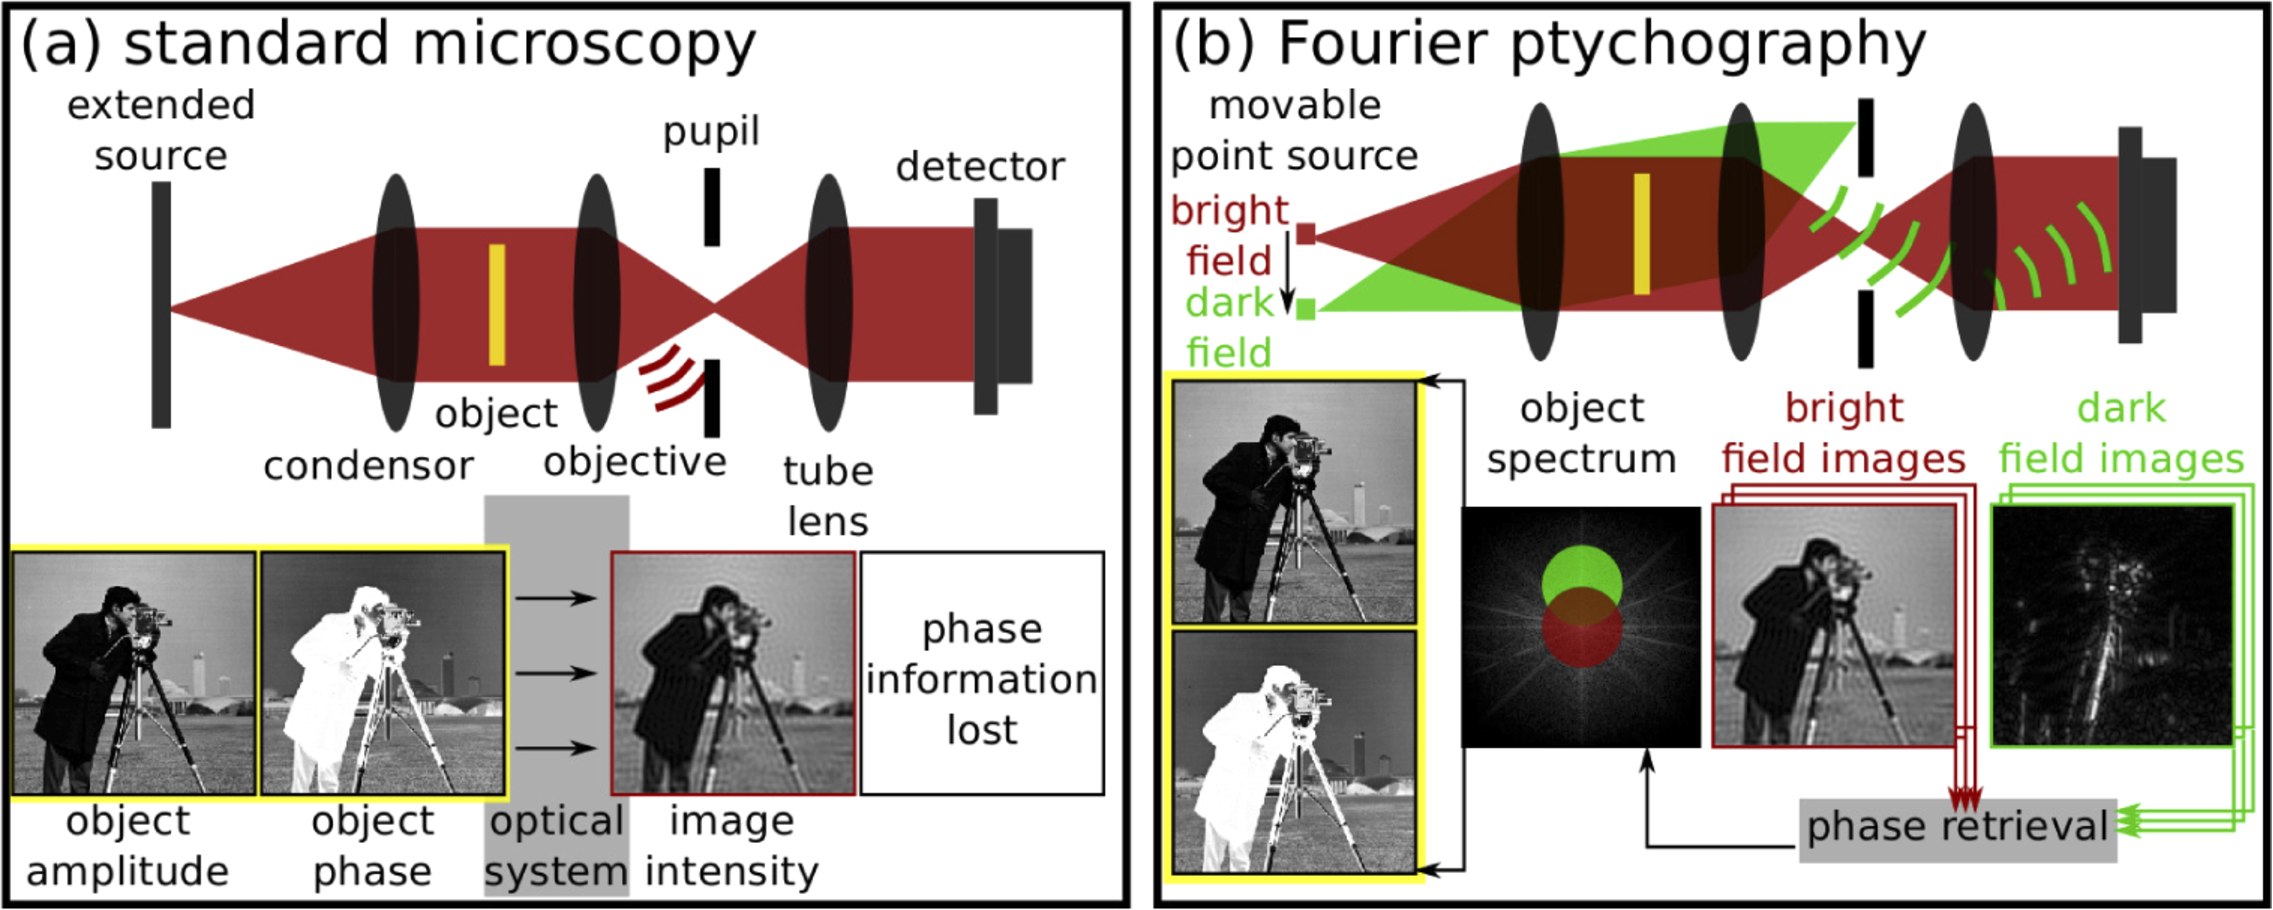

(Image from [https://doi.org/10.1364/OE.386168](https://doi.org/10.1364/OE.386168))

## Modeling Tilted Illumination Microscope

The microscope we want to model illuminates the amplitude and phase sample with tilted plane waves, relays the sample to the camera plane through a 4f system with limited NA to simulate the limited resolution of a real microscope, and then captures the intensity at the camera plane. Note that every step listed below just corresponds to just 1 or 2 lines of code using the corresponding function(s) from Chromatix!

In [7]:
def tilted_illumination_system(amplitude: Array, phase: Array, kykx: Array) -> Array:
    # 1. Start with an angled plane wave for illumination.
    # The angle is defined by a shift in Fourier (k) space, given by the kykx vector.
    # You will want to create a field with the same shape as the sample (512, 512) with
    # a pixel spacing (sampling) of 0.3 microns, and a single wavelength of 0.532 microns
    field = cx.plane_wave(amplitude.shape, 0.3, 0.532, kykx=kykx)
    # 2. Apply the amplitude of the sample to the incoming illumination field.
    field = cx.amplitude_change(field, amplitude)
    # 3. Apply the phase of the sample to the incoming field.
    field = cx.phase_change(field, phase)
    # 4. Define a 4f system to relay the illuminated sample to the camera plane!
    # You will want to use the same focal length for both lenses in this demo (1.8e3 microns),
    # with a refractive index of 1.33 and an NA in the pupil plane of 0.3.
    field = cx.ff_lens(field, 1.8e3, 1.33)
    field = cx.ff_lens(field, 1.8e3, 1.33, NA=0.3)
    # 5. Return the intensity of the field at the camera plane, since we measure intensity.
    return field.intensity

Next, we'll need to create a "sample" that we can pretend to measure with tilted illuminations. Here we'll use some default datasets from skimage.

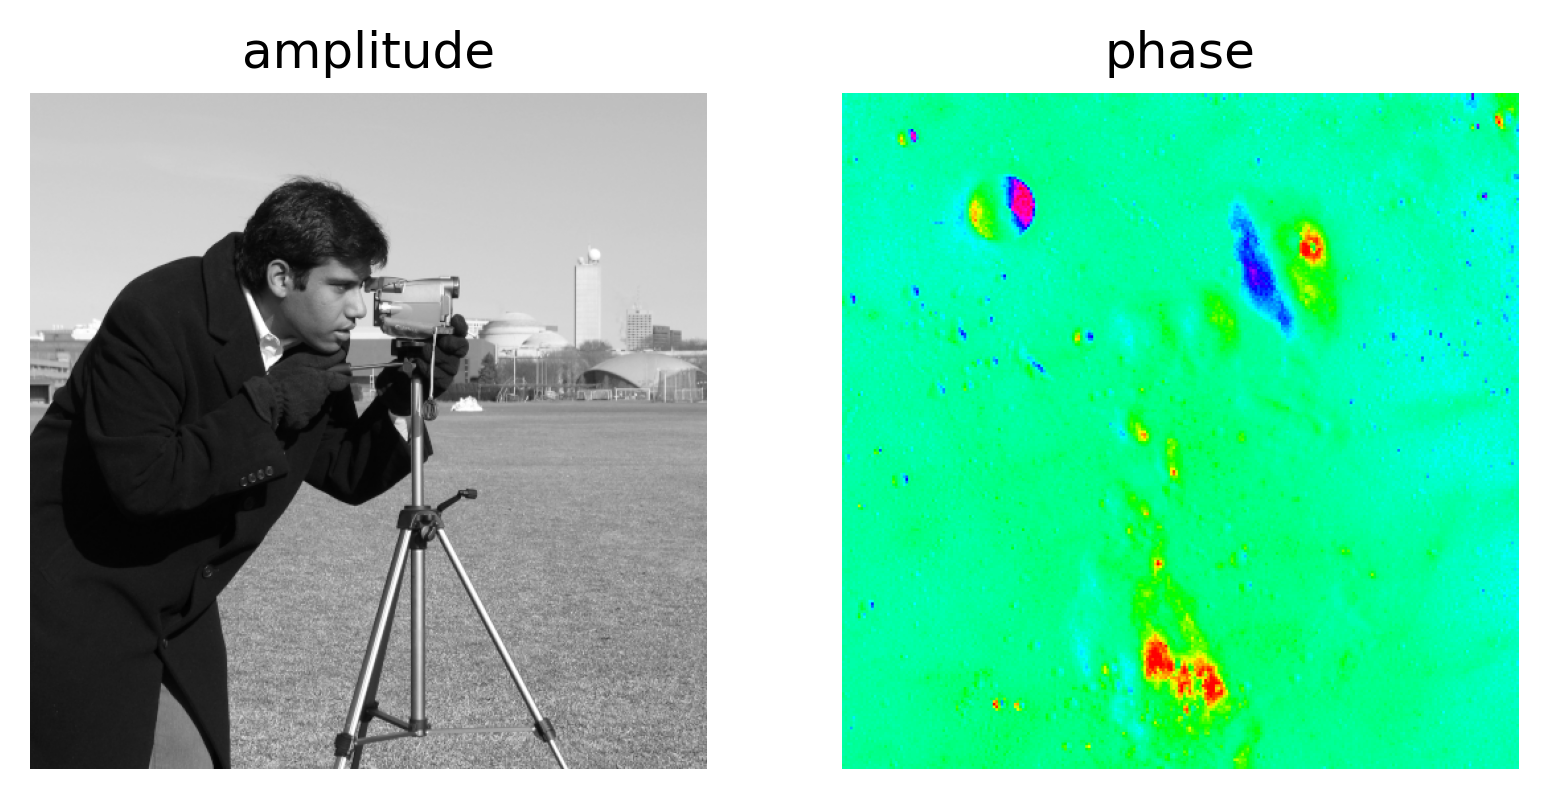

In [8]:
amplitude = skimage.data.camera().astype("float")
amplitude = amplitude / amplitude.max()
phase = skimage.data.moon().astype("float")
phase = np.pi * phase / phase.max()
show_amplitude_and_phase(amplitude, phase)

These next few lines simulate imaging the sample we just created above using 121 different angles of illumination. We'll need to capture many images at different angles of illumination to get enough information to constrain our inverse problem. You will also get an array of kykx vectors (`kykx`) that define the angle of each illumination. Normally these angles of illumination would be something you have to calibrate, but since we're simulating things we get these angles exactly. For this example, we'll pretend that these are our "measured" images.

In [9]:
kykx = (
    jnp.array(
        jnp.meshgrid(jnp.linspace(-0.5, 0.5, num=11), jnp.linspace(-0.5, 0.5, num=11))
    )
    * 2
    * jnp.pi
)
kykx = rearrange(kykx, "d h w -> (h w) d")
images = jax.vmap(
    lambda k: tilted_illumination_system(jnp.array(amplitude), jnp.array(phase), k)
)(kykx)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


This should show you the "measured" image of the sample without any tilt, so you shouldn't see very much contribution from the phase of the sample. So this should look mostly like a blurry version of the camera man, because we imaged that sample with a low NA system.

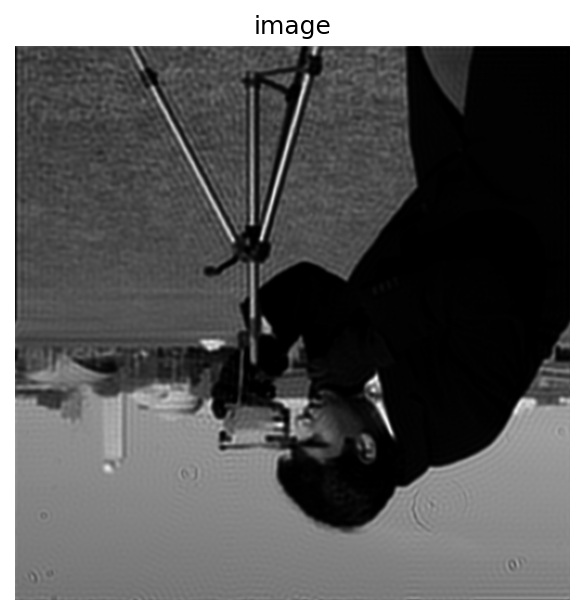

In [10]:
show_image(images[60])

This should look like the amplitude sample, but with some "shadows" coming from the larger tilt of the illumination giving you some phase contrast.

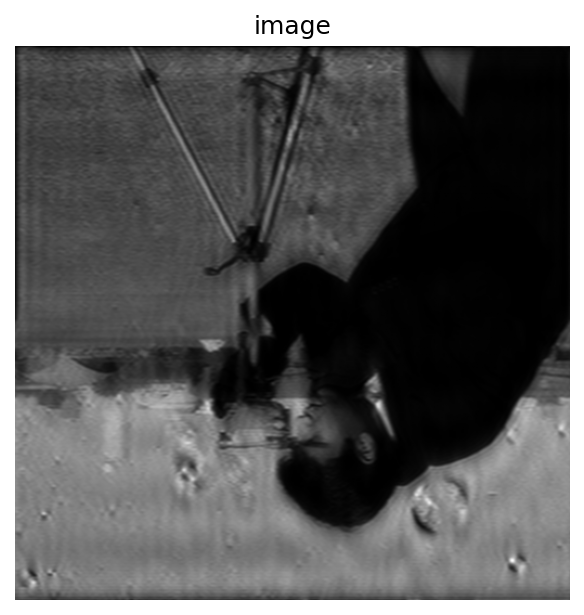

In [11]:
show_image(images[65])

This should look like a dark field image of the sample, i.e. most of the amplitude of the sample (except the highest frequencies) should be missing from this image.

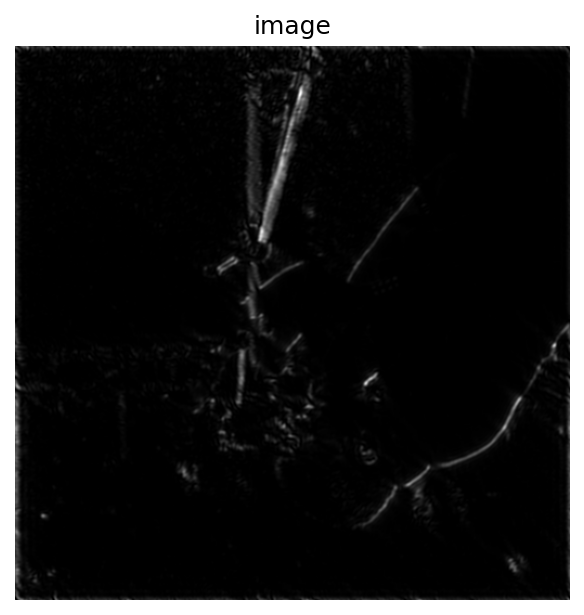

In [12]:
show_image(images[0])

## Fourier Ptychography Reconstruction with Automatic Differentiation

Here, we want to reconstruct the complex sample (amplitude and phase) at a higher resolution than we measured. While we could do this in the traditional Gerchberg-Saxton style algorithm for Fourier ptychography, here we'll take advantage of the fact that Chromatix is fully differentiable to perform this optimization. The hard part is already done, since we defined the forward model above!

Now all we need to do is to define a loss function (mean squared error) between the "measured" images and our simulations using a guess of the reconstruction, and then use gradient descent optimization to reconstruct the complex sample.

In [13]:
import numpy as np
import jax
import jax.numpy as jnp
from skimage.metrics import structural_similarity as ssim

# ------------------------------------------------------------
# STEP 1: single real measurement (central LED only)
# ------------------------------------------------------------
Ic = images[60][::-1, ::-1]

# ------------------------------------------------------------
# STEP 2: Fourier transform of central image
# ------------------------------------------------------------
Ic_fft = np.fft.fftshift(np.fft.fft2(Ic))

# ------------------------------------------------------------
# STEP 3: simulate shifted LED images via Fourier shifts
# ------------------------------------------------------------
def simulate_shifted_images(Ic_fft, kykx):
    simulated = []

    for k in range(len(kykx)):
        shift_u, shift_v = kykx[k]

        shifted = np.roll(Ic_fft, int(shift_u), axis=0)
        shifted = np.roll(shifted, int(shift_v), axis=1)

        img = np.abs(np.fft.ifft2(np.fft.ifftshift(shifted)))
        simulated.append(img)

    return np.stack(simulated)

simulated_images = simulate_shifted_images(Ic_fft, kykx)

# ------------------------------------------------------------
# STEP 4: SSIM scoring vs central image
# ------------------------------------------------------------
reference = Ic

scores = np.array([
    ssim(reference, img, data_range=img.max() - img.min())
    for img in simulated_images
])

# ------------------------------------------------------------
# STEP 5: threshold selection → binary mask A(x,y)
# ------------------------------------------------------------
H = np.percentile(scores, 30)  # paper-style manual threshold

selected_indices = np.where(scores < H)[0]

A = np.zeros(len(scores))
A[selected_indices] = 1

# ------------------------------------------------------------
# STEP 6: compressed acquisition set (true M measurements)
# ------------------------------------------------------------
images_used = images[selected_indices]
print(len(images_used))
kykx_used = kykx[selected_indices]

# ------------------------------------------------------------
# STEP 7: reconstruction setup
# ------------------------------------------------------------
parameters = (
    jax.nn.sigmoid(images_used[0]),   # amplitude init
    jnp.zeros_like(images_used[0])     # phase init
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(1e5)
)

opt_state = optimizer.init(parameters)

def loss_fn(parameters, measured_image, kykx):
    amplitude, phase = parameters
    simulated = tilted_illumination_system(amplitude, phase, kykx)
    return jnp.mean((simulated - measured_image) ** 2)

@jax.jit
def update(parameters, opt_state, image, kykx):
    loss, grads = jax.value_and_grad(loss_fn)(parameters, image, kykx)
    updates, opt_state = optimizer.update(grads, opt_state)
    parameters = optax.apply_updates(parameters, updates)
    return loss, parameters, opt_state

# ------------------------------------------------------------
# STEP 8: FPM reconstruction using ONLY selected measurements
# ------------------------------------------------------------
losses = []

for i in range(50):
    for j in range(len(selected_indices)):
        loss, parameters, opt_state = update(
            parameters,
            opt_state,
            images_used[j],
            kykx_used[j]
        )
        losses.append(np.array(loss))
    print(
        f"iteration {i+1} loss = "
        f"{np.mean(losses[-len(selected_indices):])}"
    )




36
iteration 1 loss = 1.7233138527306124e-11
iteration 2 loss = 1.1123895858264343e-12
iteration 3 loss = 4.739509566059619e-13
iteration 4 loss = 3.1070859860676814e-13
iteration 5 loss = 2.2261778195604293e-13
iteration 6 loss = 1.6866921000082552e-13
iteration 7 loss = 1.3295872107292606e-13
iteration 8 loss = 1.0818039172799665e-13
iteration 9 loss = 9.032673968598776e-14
iteration 10 loss = 7.707203609043714e-14
iteration 11 loss = 6.697804610196131e-14
iteration 12 loss = 5.911941671887105e-14
iteration 13 loss = 5.288024318016345e-14
iteration 14 loss = 4.783919774534705e-14
iteration 15 loss = 4.3701184299993825e-14
iteration 16 loss = 4.0255372955400395e-14
iteration 17 loss = 3.7348355880423637e-14
iteration 18 loss = 3.486666792958115e-14
iteration 19 loss = 3.272517551541031e-14
iteration 20 loss = 3.085910772250046e-14
iteration 21 loss = 2.921853026454507e-14
iteration 22 loss = 2.776455077673802e-14
iteration 23 loss = 2.64664744791367e-14
iteration 24 loss = 2.529981195

If everything's gone right, you should see a converging loss plot below! This shows you the average loss across all 121 images at each iteration of our optimization.

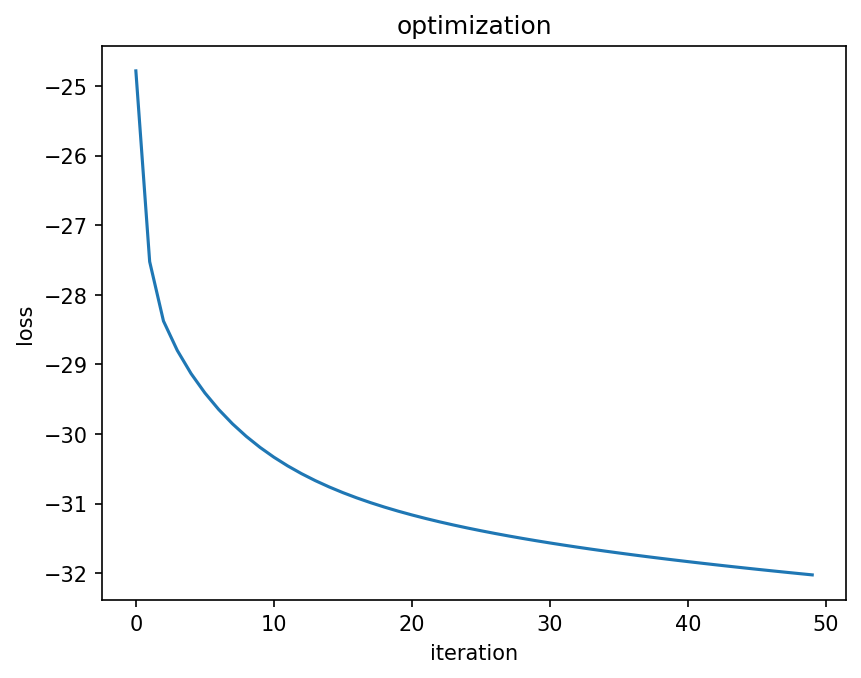

In [14]:
plot_losses(losses, 50)

And finally you should see our recovered reconstruction! You'll note that there are some artifacts... but we got a higher resolution reconstruction of the amplitude (look at the details on the hair, grass, or buttons), and an estimate of the phase of the sample.

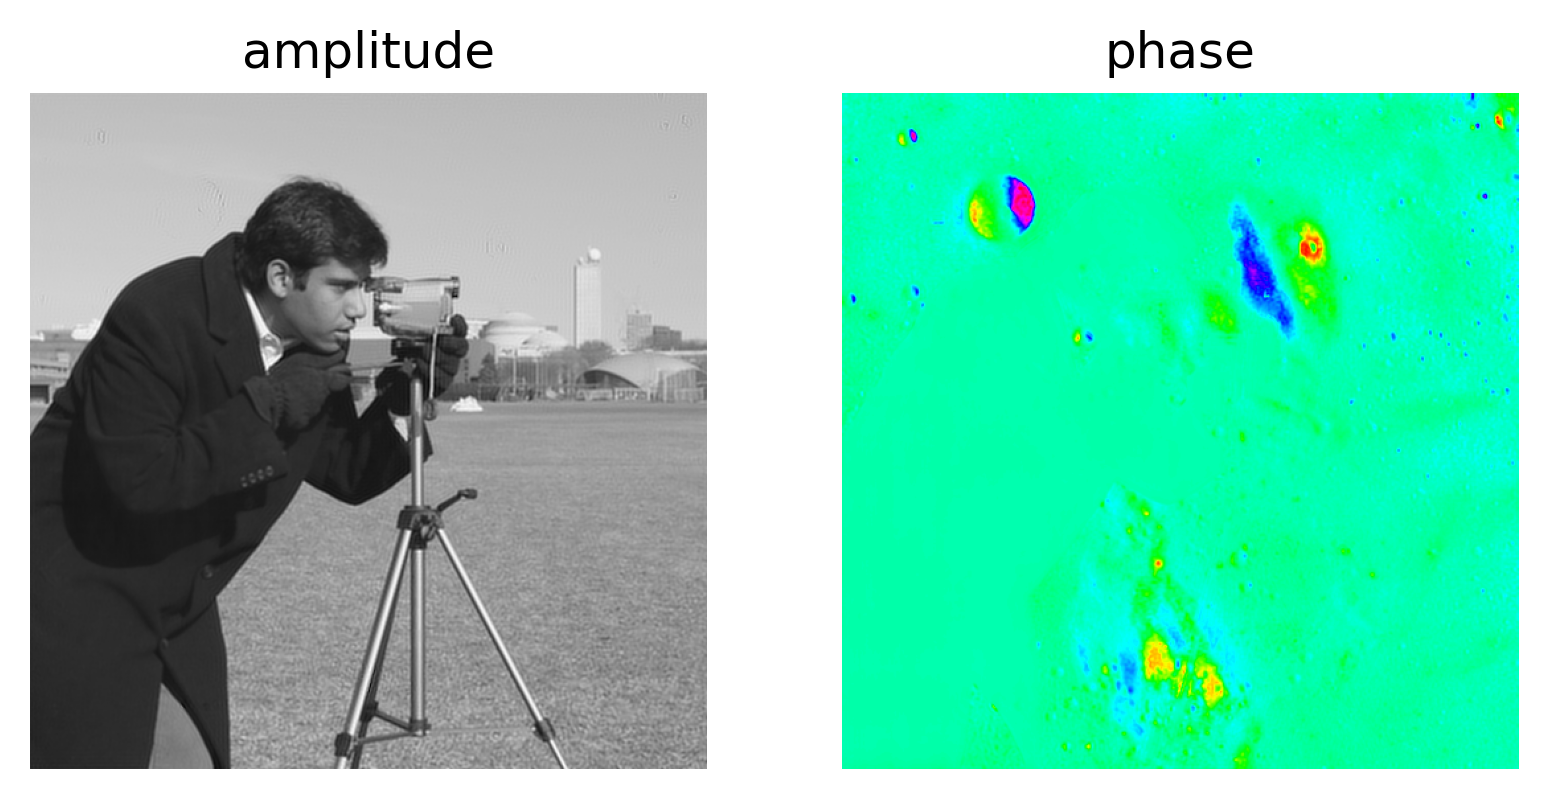

In [15]:
show_amplitude_and_phase(*parameters)

## Extensions

If you want to continue working on this demo:

1. The reconstruction above has significant artifacts. Can you play with either the angles of illumination or the optimization to improve these artifacts?
2. You can try to [install Chromatix](https://chromatix.readthedocs.io/en/latest/installing/) on your own computer with a bigger GPU and try out your own optimizations at a bigger scale than this simple demo.